In [1]:
import os
import sys
sys.path.append(os.path.abspath('../scripts'))
fig_path      = '../figures/'
data_path     = '../data/'

In [2]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
from proj_utils import *
from mapping_utils import *
from plotting_utils import *

In [23]:
import matplotlib.colors as colors

In [3]:
bathy = xr.open_dataarray(data_path + 'gebco_north_atlantic.nc')
bathy = bathy.sel(lat = slice(35,44), lon = slice(-75,-65))

/var/folders/zs/slgdfngx28q5l95vgtjw29kw0000gn/T/ipykernel_34543/1996628565.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(abs(levels))


array([3.60205999, 3.59328607, 3.58433122, 3.57518784, 3.56584782,
       3.5563025 , 3.54654266, 3.53655844, 3.52633928, 3.51587384,
       3.50514998, 3.49415459, 3.48287358, 3.47129171, 3.45939249,
       3.44715803, 3.4345689 , 3.42160393, 3.40823997, 3.39445168,
       3.38021124, 3.36548798, 3.35024802, 3.33445375, 3.31806333,
       3.30103   , 3.28330123, 3.26481782, 3.24551267, 3.22530928,
       3.20411998, 3.18184359, 3.15836249, 3.13353891, 3.10720997,
       3.07918125, 3.04921802, 3.01703334, 2.98227123, 2.94448267,
       2.90308999, 2.8573325 , 2.80617997, 2.74818803, 2.68124124,
       2.60205999, 2.50514998, 2.38021124, 2.20411998, 1.90308999,
             -inf])

In [18]:
np.log10(levels)

/var/folders/zs/slgdfngx28q5l95vgtjw29kw0000gn/T/ipykernel_34543/4012744106.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(levels)
/var/folders/zs/slgdfngx28q5l95vgtjw29kw0000gn/T/ipykernel_34543/4012744106.py:1: RuntimeWarning: invalid value encountered in log10
  np.log10(levels)


array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan, -inf])

In [34]:
shallow = np.arange(0,1000,10)
deep = np.arange(1000,5001,100)
levels = np.hstack((shallow,deep))

In [60]:
wp_lat = np.array((39.35,39.50,39.65,39.7,39.75,39.8,39.85,39.9,39.95,40.0,40.15,40.3))
wp_lon = np.zeros(len(wp_lat))
wp_lon[:] = -70.75

In [67]:
xbt_lat = np.array((39.4,39.45,39.55,39.6,40.05,40.1,40.2,40.25))
xbt_lon = np.zeros(len(xbt_lat))
xbt_lon[:] = -70.75

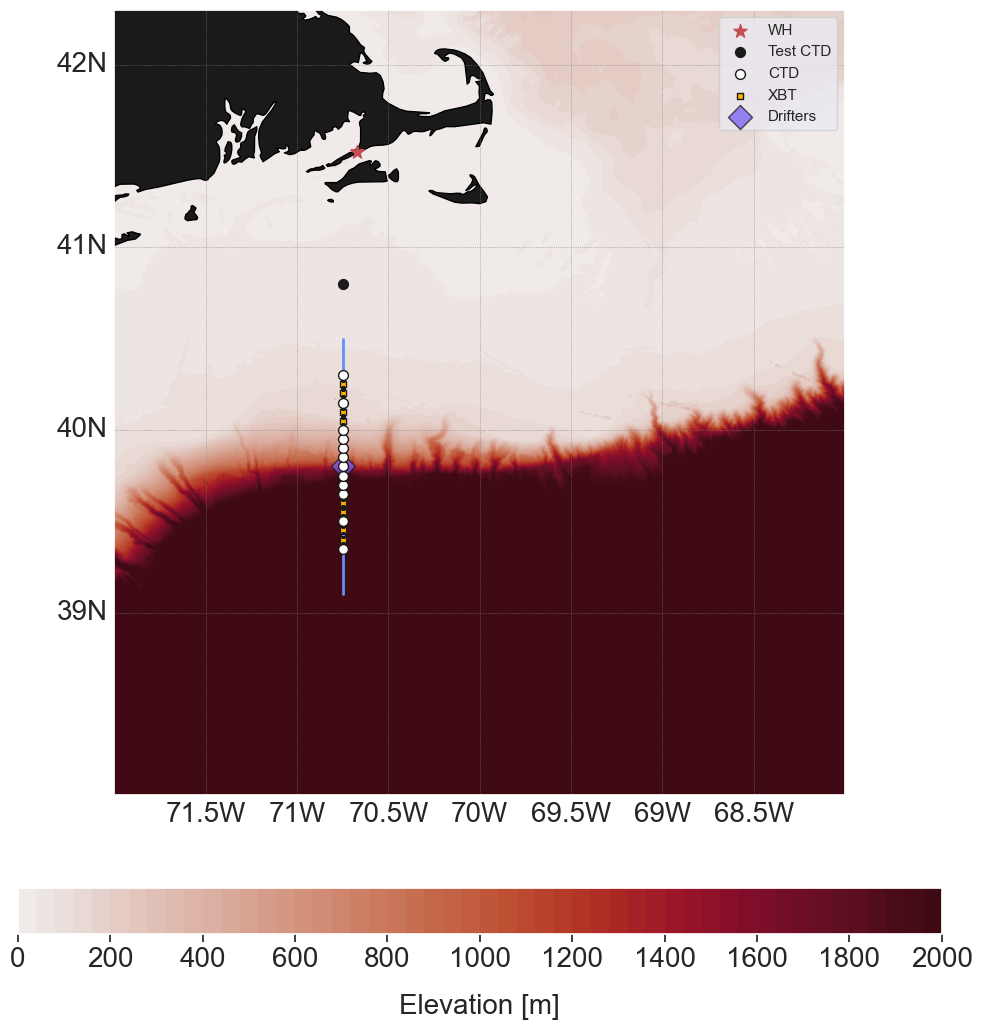

In [75]:
bbox = [288, 292, 38, 42.3]
fig = plt.figure(figsize=(16, 12))
crs = ccrs.PlateCarree()
ax = plt.subplot(1, 1, 1, projection=crs)
ax.set_extent(bbox, crs)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='k', zorder=1)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle=':')
gl.top_labels = gl.right_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(34,44))
gl.xformatter = LongitudeFormatter(degree_symbol='')
gl.yformatter = LatitudeFormatter(degree_symbol='')

var_to_plot = abs(bathy.data)
cmax = 2000
var_to_plot[var_to_plot > cmax] = cmax


levels = np.linspace(0,2000,51)
colorplot = plt.contourf(bathy.lon,bathy.lat,var_to_plot, levels = levels, cmap='cmo.amp', zorder=0)
#norm = colors.LogNorm(vmin=1, vmax=4000)  # avoid zero
#colorplot = ax.contourf(bathy.lon,bathy.lat,abs(bathy), levels=100, norm=norm, cmap='viridis')

plt.xlabel('Latitude ', fontsize=25)
plt.ylabel('Longitude', fontsize=25)
gl.xlabel_style = {'size': 20}
gl.ylabel_style = {'size': 20}

plt.scatter(-70.671628,41.523683,s = 100, c = 'r', marker = '*', label = 'WH',zorder = 100)
#plt.scatter(-70.5, 40.5, s = 100, c = 'r', marker = '*')
plt.scatter(-70.75,40.8, s = 50, c = 'k', edgecolors= 'k', marker = 'o',zorder =10, label = 'Test CTD')

plt.scatter(wp_lon,wp_lat, s = 50, c = 'w', edgecolors= 'k', marker = 'o',zorder =10, label = 'CTD')
plt.scatter(xbt_lon,xbt_lat, s = 20, c = '#ffb000', edgecolors= 'k', marker = 's',zorder =8, label = 'XBT')
plt.scatter(-70.75,39.8, s = 150, c = '#785ef0', edgecolors= 'k', alpha =0.75,marker = 'D',zorder =5, label = 'Drifters')

plt.plot(np.array((-70.75,-70.75)), np.array((39.1,40.5)), linewidth = 2, c = '#648fff',zorder = 5)
cbar = plt.colorbar(colorplot, fraction=0.05, pad=0.1, orientation='horizontal',
                    ticks=np.linspace(0, 2000, 11))
cbar.set_label('Elevation [m]', size='20', labelpad=15)
cbar.ax.tick_params(labelsize=20)
plt.legend()
#plt.savefig(fig_path + 'gsi_std_altimetry.png', format='png', bbox_inches="tight",dpi=500)

In [5]:
bathy.sel(lat =  40.5, lon = -70.5, method = 'nearest')
bathy.sel(lat =  39.2, lon = -70.5, method = 'nearest')

<xarray.DataArray 'elevation' ()> Size: 2B
array(-2736, dtype=int16)
Coordinates:
    lat      float64 8B 39.2
    lon      float64 8B -70.5
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres